### Load Dataset


In [2]:
# Import Libraries
import pandas as pd
import numpy as np

# LOad daatset
df = pd.read_csv("sales.csv")

# Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
# Check dataset shape
df.shape

# Check column names
df.columns

# Check datatypes and missing values
df.info()

# Summary Statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000



## 🧹 Data Cleaning

In this step, unnecessary and irrelevant columns were removed to simplify the dataset and focus on meaningful analysis.

The following columns were dropped:

* **Row ID, Order ID, Customer ID** → Unique identifiers with no analytical value
* **Customer Name** → Too granular for analysis
* **Postal Code** → Contains missing values and not useful for this analysis
* **Product ID** → Redundant since Product Name is available

This helps improve data clarity and prepares the dataset for further analysis.


In [4]:
# Check missing values
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [5]:
# Remove irrelevant columns
df = df.drop(columns=['Row ID', 'Order ID', 'Customer ID', 'Customer Name', 'Postal Code', 'Product ID'])
df.head()

,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Product Name,Sales
0,08/11/2017,11/11/2017,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,08/11/2017,11/11/2017,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,12/06/2017,16/06/2017,Second Class,Corporate,United States,Los Angeles,California,West,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,11/10/2016,18/10/2016,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,11/10/2016,18/10/2016,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## 📊 Exploratory Data Analysis (EDA)

In this section, we explore the dataset to identify patterns, trends, and relationships between different variables. Visualizations are used to better understand sales performance across time, categories, and regions.


### 📊 Total Sales Analysis

The total sales across the dataset provide a high-level overview of the business performance.


In [6]:
total_sales = df['Sales'].sum()
print("Total Sales: ", total_sales)

Total Sales:  2261536.7827000003



### 💡 Insight

The overall sales amount indicates the scale of business operations and revenue generation. This serves as a baseline for comparing performance across different segments, categories, and time periods.


### 📈 Sales Over Time

Sales were analyzed on a yearly basis to identify trends and growth patterns over time.

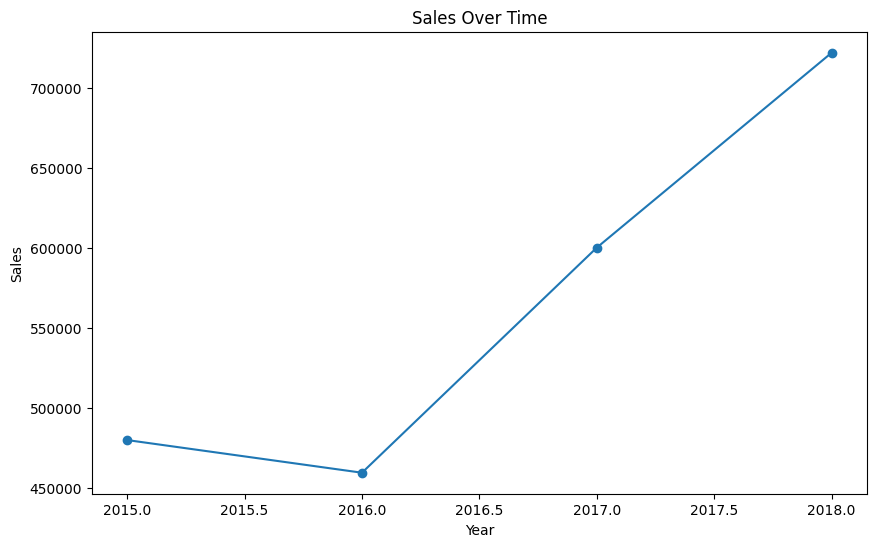

In [7]:
import matplotlib.pyplot as plt

# Extract year from the column
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Year'] = df['Order Date'].dt.year

# Group by year
yearly_sales = df.groupby('Year')['Sales'].sum()

# Plot
plt.figure(figsize=(10,6))
yearly_sales.plot(kind='line', marker='o')
plt.title('Sales Over Time')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.show()



### 💡 Insight

Sales show an overall increasing trend over the years. There is a slight decline in 2016, followed by significant growth in 2017 and 2018. This suggests improving business performance, increased demand, or successful business strategies implemented in later years.


### 📦 Sales by Category

Sales were analyzed across different product categories to understand their contribution to total revenue.

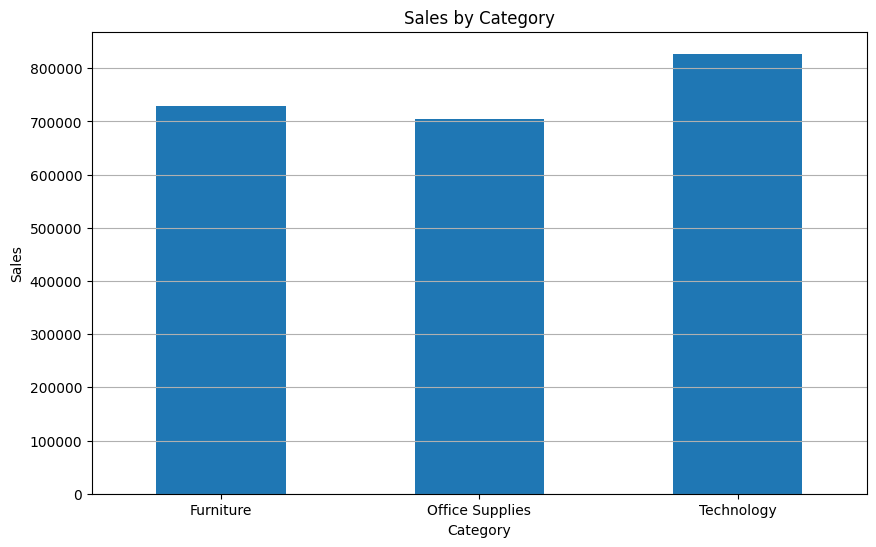

In [8]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(10,6))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()



### 💡 Insight

The Technology category generates the highest sales, followed by Furniture and Office Supplies. This indicates that technology products are the primary drivers of revenue, possibly due to higher prices or strong customer demand.


### Monthly Sales Trend (Seasonality)

Monthly sales are aggregated to observe how revenue is distributed across different months of the year. This analysis helps visualize variations in sales over time at a monthly level.


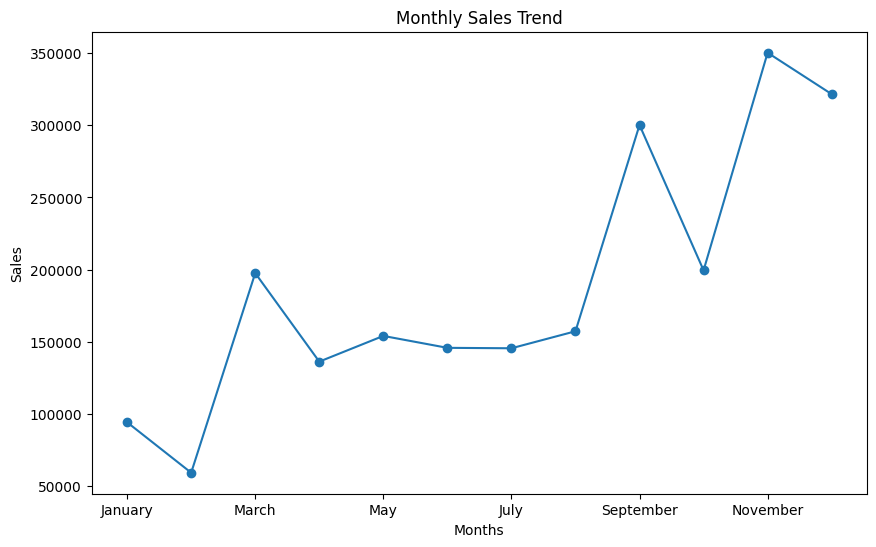

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Month_name'] = df['Order Date'].dt.month_name()

monthly_sales = df.groupby('Month_name')['Sales'].sum()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(10,6))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Months')
plt.ylabel('Sales')
plt.show()

### 💡 Insight

Monthly sales exhibit clear seasonal patterns. Sales are relatively low at the beginning of the year, especially in February, and gradually increase towards the later months. A significant rise is observed from September onwards, with peak sales in November and December. This trend suggests higher demand during the holiday season and year-end period, which is common in retail businesses.


## 🌍 Regional Sales Analysis

Sales are aggregated by region to compare performance across different geographic areas. This visualization highlights how revenue is distributed among the regions.



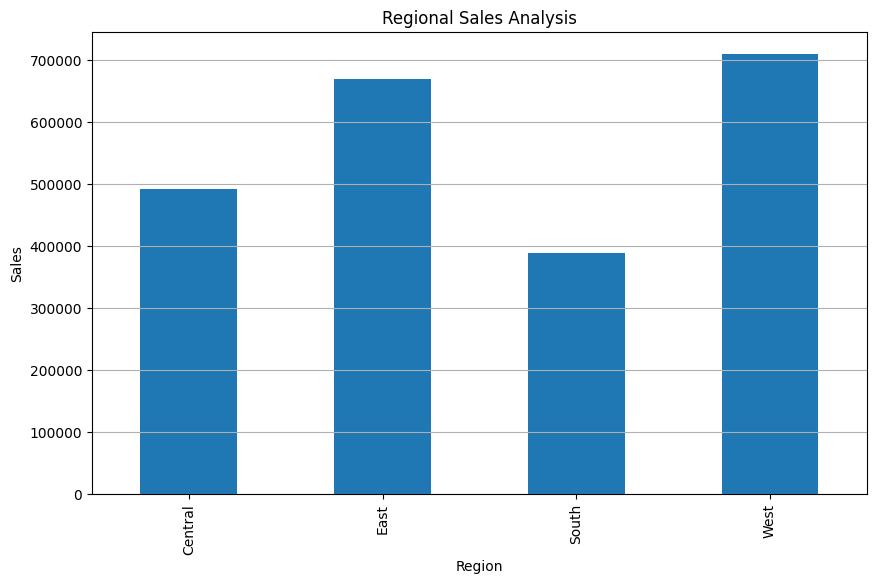

In [13]:
regional_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(10,6))
regional_sales.plot(kind='bar')
plt.title('Regional Sales Analysis')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.grid(axis='y')
plt.show()

### 💡 Insight

The West region generates the highest sales, followed by the East and Central regions, while the South region contributes the least. This indicates that sales performance varies significantly across regions, with stronger revenue generation concentrated in the West and East.


## 🏆 Top Products Analysis

Sales are analyzed at the product level to identify the highest-performing products contributing to overall revenue.


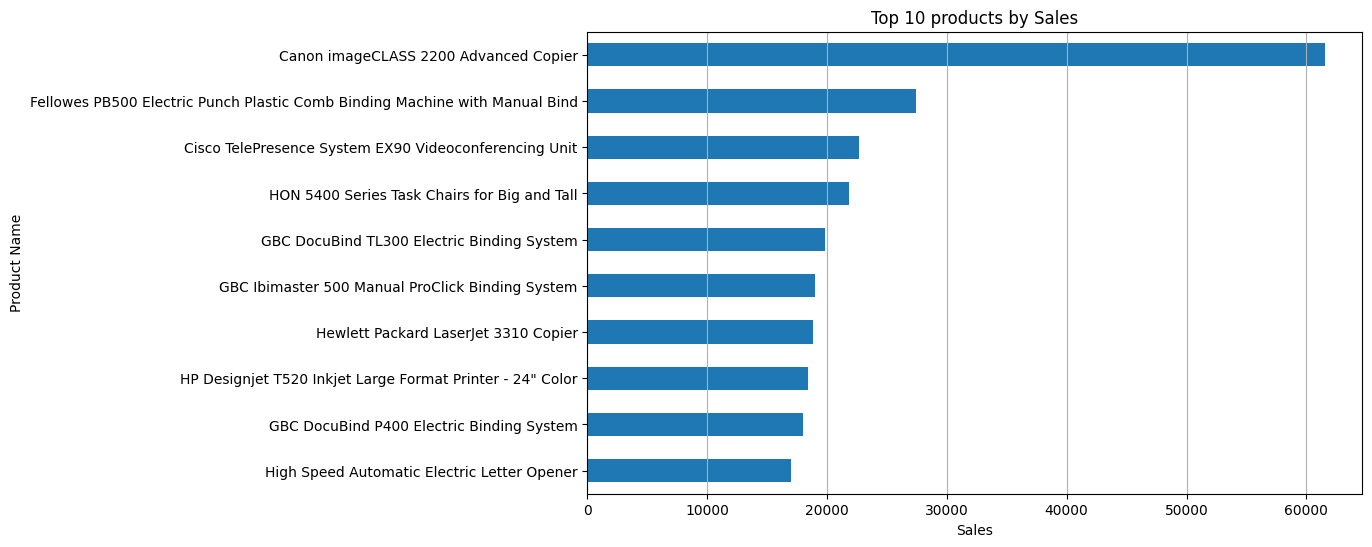

In [18]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind='barh')
plt.title('Top 10 products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product Name')
plt.grid(axis='x')
plt.show()

### 💡 Insight

The Canon imageCLASS 2200 Advanced Copier is the top-performing product by a significant margin, generating much higher sales than other products. The remaining top products show relatively similar sales levels, indicating that while multiple products contribute to revenue, a single product stands out as a major driver of sales.
